# Digitalna obrada govornog signala sa mrežnom smetnjom od 50 Hz

U ovom projektu analizira se kratak govorni signal u WAV formatu.  
Na originalni govorni signal dodaje se mrežna smetnja frekvencije 50 Hz, koja predstavlja realan problem kod audio snimanja usled uticaja električne mreže, napajanja računara, punjača ili okolnih električnih uređaja.

Cilj projekta je da se prikaže uticaj mrežne smetnje na govorni signal, izvrši analiza signala u vremenskom i frekvencijskom domenu, a zatim projektuju i uporede dva tipa digitalnih filtera:

- Butterworth IIR filter,
- FIR filter projektovan prozorskom metodom.

Nakon filtriranja porede se originalni signal, signal sa dodatom smetnjom i filtrirani signali.

## 1. Uvoz biblioteka

Na početku se uvoze biblioteke potrebne za numeričku obradu, učitavanje WAV fajla, prikaz grafika, Furijeovu analizu, projektovanje digitalnih filtera i preslušavanje audio signala u Jupyter Notebook-u.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy import signal
from IPython.display import Audio

In [2]:
# Podešavanje prikaza grafika
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 2. Učitavanje govornog signala

U ovom delu se učitava govorni signal koji ćemo obraditi.

Za obradu je korišćen sopstveni govorni snimak pod nazivom `SnimakGlasa.wav`. 
Snimak je mono, frekvencije odabiranja 16 kHz i trajanja približno 20 s. 
Signal je snimljen mikrofonom/laptopom i predstavlja realan diskretni govorni signal.

Nakon učitavanja prikazuju se osnovne informacije o signalu:

- frekvencija odabiranja,
- broj odbiraka,
- trajanje signala,
- maksimalna amplituda.

In [3]:
# Naziv audio fajla
filename = "Audio/SnimakGlasa.wav"

# Učitavanje WAV fajla
fs, x = wavfile.read(filename)

# Provera dimenzije signala
print(f"Dimenzija učitanog signala: {x.shape}")
print(f"Tip podataka pre obrade: {x.dtype}")

Dimenzija učitanog signala: (319760,)
Tip podataka pre obrade: int16


Originalni WAV signal je učitan u svom početnom formatu, a zatim je za potrebe obrade konvertovan u `float` format i normalizovan na opseg od -1 do 1. Normalizacija omogućava jednostavnije dodavanje mrežne smetnje kontrolisane amplitude i poređenje rezultata filtriranja.

In [4]:
# Pretvaranje u float format
x = x.astype(float)

# Normalizacija signala na opseg [-1, 1]
x = x / np.max(np.abs(x)) # normalizacija se radi da bi se lakše baratalo sa amplitudom smetnje, u originalnom fajlu je amplituda 6.5 decibela, provera kroz Audacity

# Osnovni parametri signala
N = len(x)
duration = N / fs
max_amplitude = np.max(np.abs(x)) # bice 1 nakon normalizacije naravno

print(f"Frekvencija odabiranja: {fs} Hz")
print(f"Broj odbiraka: {N}")
print(f"Trajanje signala: {duration:.2f} s")
print(f"Maksimalna amplituda nakon normalizacije: {max_amplitude:.2f}")

Frekvencija odabiranja: 16000 Hz
Broj odbiraka: 319760
Trajanje signala: 19.98 s
Maksimalna amplituda nakon normalizacije: 1.00


In [5]:
# Vremenska osa
t = np.arange(N) / fs

## 3. Preslušavanje originalnog signala

Pre dodavanja mrežne smetnje, originalni govorni signal se može preslušati direktno u notebook-u. Na ovaj način se proverava da li je signal pravilno učitan i da li odgovara očekivanom govornom sadržaju.

In [ ]:
Audio(x, rate=fs)

## 4. Prikaz originalnog signala u vremenskom domenu

Govorni signal se prvo prikazuje u vremenskom domenu. Na horizontalnoj osi nalazi se vreme u sekundama, dok je na vertikalnoj osi normalizovana amplituda signala.

Ovaj prikaz omogućava uvid u promenu amplitude govora tokom vremena.

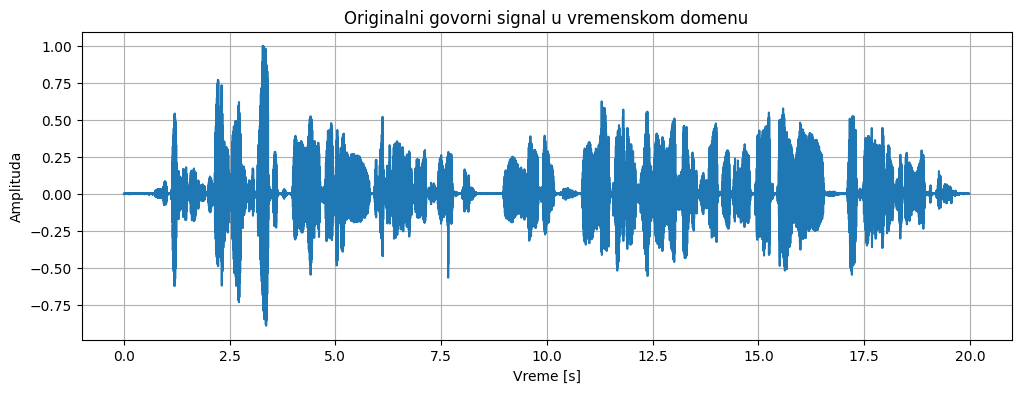

In [7]:
plt.figure()
plt.plot(t, x)
plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Originalni govorni signal u vremenskom domenu")
plt.show()

## 5. Zumirani prikaz originalnog signala

Pošto govorni signal traje približno 20 sekundi, na celom vremenskom prikazu se ne vide detalji pojedinačnih oscilacija. Zbog toga se prikazuje i kraći vremenski interval, na primer od 2.5 sekunde do 2.8 sekunde jer tu ima veća aktivnost.

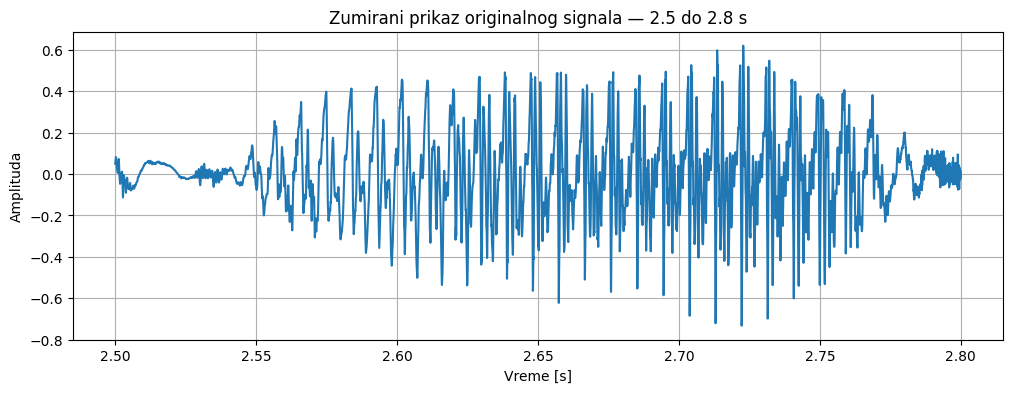

In [34]:
#Do intervala smo došli empirijskim putem - pogledali smo originalni signal i primetili zone veće aktivnosti
start_time = 2.5
end_time = 2.8

# Pošto je fs broj odbiraka u jednoj sekundi, množenjem vremena sa fs
# dobija se broj odbiraka koji odgovara tom vremenskom intervalu.

# Pretvaranje vremenskog intervala u indekse odbiraka
start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

plt.figure()
plt.plot(t[start_sample:end_sample], x[start_sample:end_sample])
plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Zumirani prikaz originalnog signala — 2.5 do 2.8 s")
plt.show()

## 6. Dodavanje mrežne smetnje od 50 Hz

U ovom delu se originalnom govornom signalu dodaje mrežna smetnja frekvencije 50 Hz.

Mrežna smetnja se modeluje kao sinusni diskretni signal:

$$
s[n] = A \sin \left( 2 \pi f_0 \frac{n}{f_s} \right)
$$

gde je:

- $A$ amplituda smetnje,
- $f_0 = 50\,\text{Hz}$ frekvencija mrežne smetnje,
- $f_s$ frekvencija odabiranja,
- $n$ indeks odbirka.

Za amplitudu mrežne smetnje izabrana je vrednost $A = 0.13$, što odgovara približno 13% maksimalne amplitude normalizovanog govornog signala. Ova vrednost je izabrana tako da smetnja bude jasno uočljiva u frekvencijskom spektru, ali da ne potisne potpuno govorni signal.

In [20]:
# Parametri mrežne smetnje
f0 = 50          # frekvencija mrežne smetnje [Hz]
A_noise = 0.13   # amplituda smetnje, uzimamo sitnu vrednost zbog dominantnosti originalnog signala, ali opet primetna da bude smetnja

# Generisanje sinusne smetnje
network_noise = A_noise * np.sin(2 * np.pi * f0 * t)

# Dodavanje smetnje originalnom signalu
x_noisy = x + network_noise
print(np.max(np.abs(x_noisy)))

1.1283994842773695


Maksimalna amplituda zašumljenog signala iznosi približno 1.12. 
Pošto se signal u ovoj fazi koristi za numeričku analizu u `float` formatu, 
ovo ne predstavlja problem. Dodatna normalizacija nije primenjena kako bi se očuvao 
tačan odnos između amplitude govornog signala i dodate mrežne smetnje.

## 7. Preslušavanje signala sa dodatom mrežnom smetnjom

Nakon dodavanja mrežne smetnje, signal se može preslušati.  
Pošto je smetnja male amplitude, možda neće biti veoma izražena pri slušanju, ali se očekuje da bude jasno vidljiva u frekvencijskom domenu.

In [35]:
Audio(x_noisy, rate=fs)

## 8. Prikaz mrežne smetnje u vremenskom domenu

Pre poređenja sa govornim signalom, prikazuje se sama sinusna mrežna smetnja od 50 Hz.  
Pošto je frekvencija smetnje 50 Hz, njena perioda iznosi:

$$
T = \frac{1}{50} = 0.02 \, \text{s}
$$

Zbog toga se na kratkom vremenskom intervalu može jasno videti sinusni oblik smetnje.

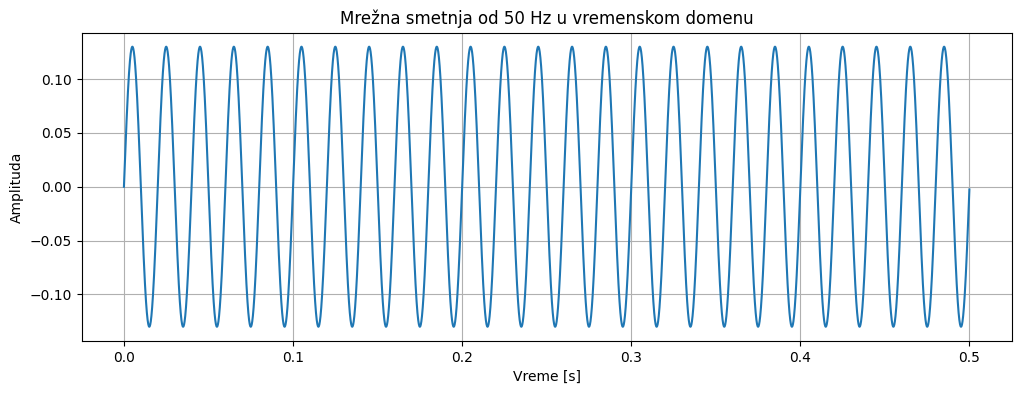

In [22]:
# Prikaz prvih 0.5 s mrežne smetnje
time_limit = 0.5
samples_limit = int(time_limit * fs)

plt.figure()
plt.plot(t[:samples_limit], network_noise[:samples_limit])
plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Mrežna smetnja od 50 Hz u vremenskom domenu")
plt.show()

Vidno je da je signal pravilno periodičan što smo i očekivali nakon slušanja zašumljenog audio zapisa.

## 9. Poređenje originalnog i zašumljenog signala u vremenskom domenu

Na sledećem grafiku prikazani su originalni govorni signal i signal nakon dodavanja mrežne smetnje.  
Pošto je amplituda smetnje relativno mala u odnosu na govor, razlika u vremenskom domenu možda neće biti veoma izražena na celom trajanju signala.

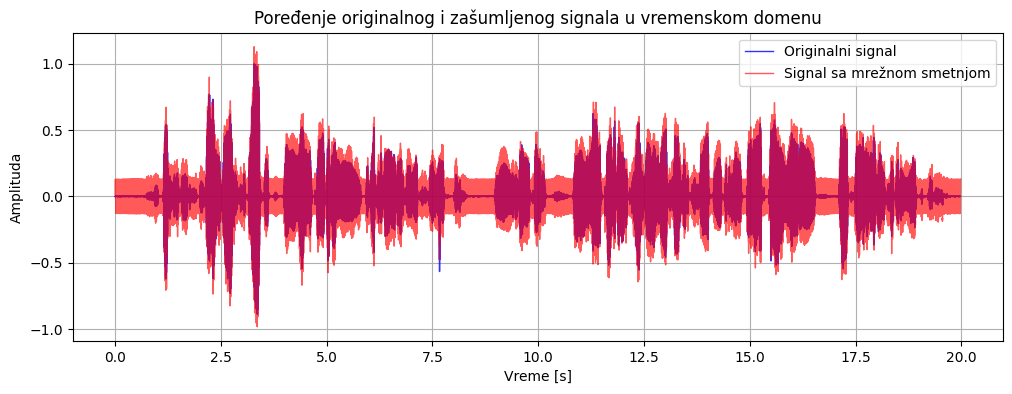

In [44]:
plt.figure()
plt.plot(t, x, label="Originalni signal", color="blue", alpha=0.8, linewidth=1)
plt.plot(t, x_noisy, label="Signal sa mrežnom smetnjom", color="red", alpha=0.65, linewidth=1)

plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Poređenje originalnog i zašumljenog signala u vremenskom domenu")
plt.legend()
plt.show()

## 10. Zumirani prikaz originalnog i zašumljenog signala

Radi jasnijeg poređenja prikazuje se vremenski interval od 2.5 s do 5 s, jer se u tom delu snimka nalazi izraženija govorna aktivnost.

Na ovom prikazu se lakše može uočiti kako dodata sinusna mrežna smetnja utiče na oblik govornog signala.

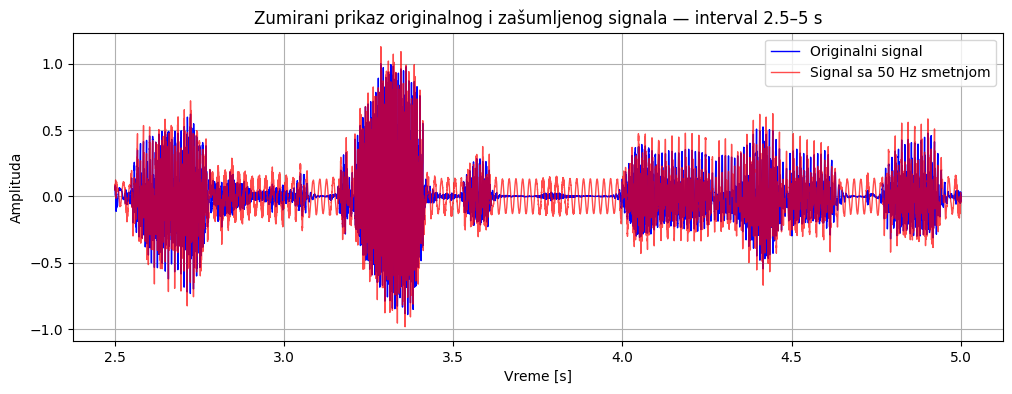

In [43]:
start_time = 2.5
end_time = 5.0

# Pretvaranje vremenskog intervala u indekse odbiraka
start_sample = int(start_time * fs)
end_sample = int(end_time * fs)

plt.figure()

#Biramo vremenski isečak gde primećujemo veću aktivnost putem t[početni:krajnji]
plt.plot(t[start_sample:end_sample], x[start_sample:end_sample],
         label="Originalni signal", color="blue", alpha=1, linewidth=1)

plt.plot(t[start_sample:end_sample], x_noisy[start_sample:end_sample],
         label="Signal sa 50 Hz smetnjom", color="red", alpha=0.7, linewidth=1)

plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Zumirani prikaz originalnog i zašumljenog signala — interval 2.5–5 s")
plt.legend()
plt.show()

## 11. FFT analiza originalnog i zašumljenog signala

Nakon dodavanja mrežne smetnje, signal se analizira u frekvencijskom domenu pomoću brze Furijeove transformacije, odnosno FFT algoritma.

FFT omogućava da se vremenski signal prikaže preko njegovih frekvencijskih komponenti. Kod originalnog govornog signala očekuje se širi frekvencijski sadržaj, dok se kod zašumljenog signala očekuje izražena komponenta na 50 Hz, koja potiče od dodate mrežne smetnje.

Pošto su audio signali realni, prikazuje se jednostrani amplitudski spektar od 0 Hz do Nikvistove frekvencije.

In [45]:
def compute_single_sided_spectrum(signal_data, fs):
    """
    Funkcija računa jednostrani amplitudski spektar realnog signala.
    """
    N = len(signal_data)

    # Koristimo .rfft kao real FFT da računamo samo pozitivne delove spektra,
    # s obzirom da je glasovni snimak realan signal.
    # FFT realnog signala
    spectrum = np.fft.rfft(signal_data)

    # Frekvencijska osa
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # Amplitudski spektar
    amplitude = np.abs(spectrum) / N

    # Korekcija amplitude za jednostrani spektar
    # Kod jednostranog spektra prikazuju se samo pozitivne frekvencije.
    # Zato se amplitude svih komponenti osim DC i Nikvistove frekvencije množe sa 2.
    # (DC je na indeksu 0, Nikvistova na -1)
    amplitude[1:-1] = 2 * amplitude[1:-1]

    return freqs, amplitude

In [46]:
# Računanje spektara originalnog i zašumljenog signala
freqs_original, amplitude_original = compute_single_sided_spectrum(x, fs)
freqs_noisy, amplitude_noisy = compute_single_sided_spectrum(x_noisy, fs)

## 12. Poređenje spektara originalnog i zašumljenog signala

Na sledećem grafiku prikazani su amplitudski spektri originalnog signala i signala sa dodatom mrežnom smetnjom.

Posebno je važan deo oko 50 Hz, jer se na toj frekvenciji očekuje komponenta koja potiče od mrežne smetnje.

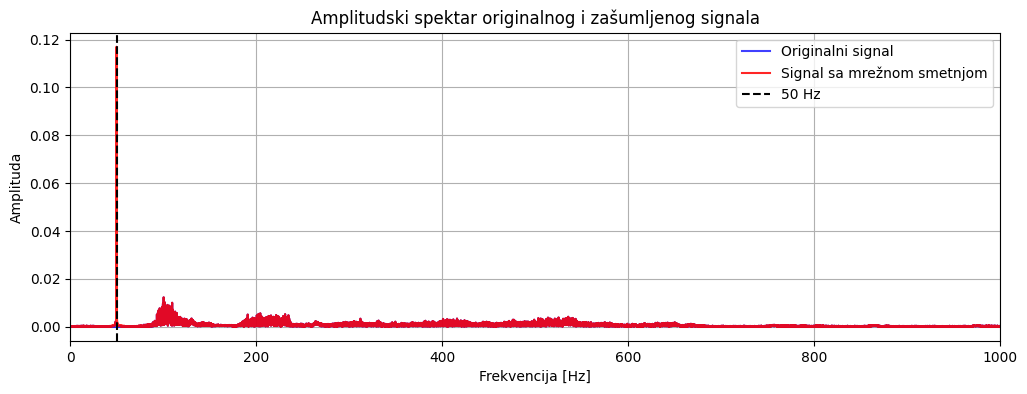

In [ ]:
freq_limit = 1000

plt.figure()
plt.plot(freqs_original, amplitude_original, label="Originalni signal", color="blue", alpha=0.75)
plt.plot(freqs_noisy, amplitude_noisy, label="Signal sa mrežnom smetnjom", color="red", alpha=0.85)
plt.axvline(50, linestyle="--", color="black", label="50 Hz") #Dodajemo vertikalnu liniju da prikažemo ključni deo

plt.xlim(0, freq_limit)
plt.xlabel("Frekvencija [Hz]")
plt.ylabel("Amplituda")
plt.title("Amplitudski spektar originalnog i zašumljenog signala")
plt.legend()
plt.show()

## 13. Uvećani prikaz spektra oko 50 Hz

Da bi se mrežna smetnja jasnije uočila, prikazuje se uži frekvencijski opseg od 40 Hz do 60 Hz.

U ovom opsegu se očekuje izražen pik na 50 Hz kod zašumljenog signala, dok je kod originalnog govornog signala ta komponenta znatno manja.

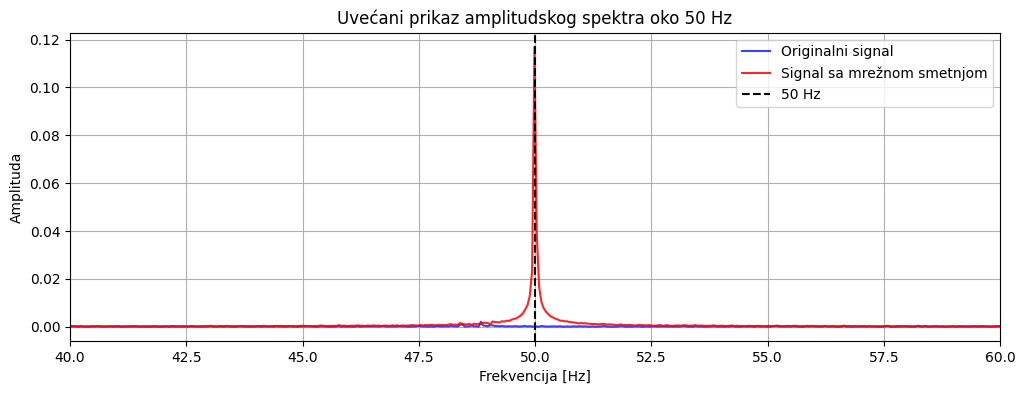

In [49]:
plt.figure()

plt.plot(freqs_original, amplitude_original,
         label="Originalni signal", color="blue", alpha=0.75)

plt.plot(freqs_noisy, amplitude_noisy,
         label="Signal sa mrežnom smetnjom", color="red", alpha=0.85)

plt.axvline(50, linestyle="--", color="black", label="50 Hz") #Higlighting donekle kao i u prethodnoj ćeliji

plt.xlim(40, 60)
plt.xlabel("Frekvencija [Hz]")
plt.ylabel("Amplituda")
plt.title("Uvećani prikaz amplitudskog spektra oko 50 Hz")
plt.legend()
plt.show()

In [ ]:
# Indeks frekvencije najbliže 50 Hz
# U suštini, redosled koraka je sledeći:
# Imamo freqs_noisy kao niz FFT amplituda za frekvencije
# Oduzimamo 50 da bi videli koliko je svaka freq udaljena od 50Hz
# Nakon toga radimo abs jer nas zanima relativna distanca
# Na kraju argmin nam vraća POZICIJU u nizu na kojoj je freq najbliža 50Hz
idx_50 = np.argmin(np.abs(freqs_noisy - 50))

print(f"Frekvencija najbliža 50 Hz: {freqs_noisy[idx_50]:.2f} Hz")
print(f"Amplituda originalnog signala na toj frekvenciji: {amplitude_original[idx_50]:.6f}")
print(f"Amplituda zašumljenog signala na toj frekvenciji: {amplitude_noisy[idx_50]:.6f}")

Frekvencija najbliža 50 Hz: 49.99 Hz
Amplituda originalnog signala na toj frekvenciji: 0.000085
Amplituda zašumljenog signala na toj frekvenciji: 0.116990


Na osnovu numeričke provere vidi se da je frekvencija najbliža ciljanoj mrežnoj smetnji veoma blizu 50 Hz. To je očekivano, jer je mrežna smetnja u signal dodata kao sinusna komponenta frekvencije $f_0 = 50\,\text{Hz}$.

Amplituda originalnog signala na toj frekvenciji predstavlja prirodni sadržaj govornog signala u okolini 50 Hz. Pošto govor uglavnom zauzima širi frekvencijski opseg, ova komponenta kod originalnog signala nije dominantna.

Kod zašumljenog signala amplituda na istoj frekvenciji je znatno veća. Razlog za to je dodata sinusna mrežna smetnja amplitude $A = 0.13$, koja direktno povećava spektralnu komponentu na 50 Hz.

Ovaj rezultat potvrđuje da je mrežna smetnja uspešno dodata signalu. Takođe pokazuje da je smetnja uskopojasna, jer se javlja kao izražen pik na jednoj frekvenciji. Zbog toga je za njeno uklanjanje pogodno koristiti notch ili uskopojasni band-stop filter oko 50 Hz.